# Nearest Centroid Classification

## Overview

This notebook explores the Nearest Centroid Classifier as a simple distance-based method for supervised classification. The goal is to understand how class centroids can be used to assign new data points to the nearest class based on Euclidean distance.

The classifier is implemented from scratch using NumPy. During training, the mean vector of each class is computed and stored as the class centroid. During prediction, each sample is assigned to the class whose centroid has the smallest Euclidean distance.

The method is applied to several synthetic two-dimensional datasets, including two-class and three-class problems with both spherical and correlated covariance structures. These examples illustrate how the geometry of the data affects the behavior of a centroid-based classifier.

The notebook also visualizes the generated datasets, class centroids, and classification behavior, providing an intuitive interpretation of how the Nearest Centroid Classifier works.

## Setup and Imports

In [1]:
# imports for plotting, numerical operations
import matplotlib.pylab as pl
import numpy as np
from numpy.random import multivariate_normal as mvn

# np.random.seed(42)

## Data Generation Functions

The following functions generate 
- two class data set with spherical covariance (uncorrelated data)
- two class data set with non-spherical covariance (correlated data)
- three class data set with non-spherical covariance (correlated data)


In [3]:
def make_data_threeclass(N=90):
    mu = np.array([[0,3],[0,-3],[2,1]]).T
    C = np.array([[5.,4.],[4.,5.]])
    n_samples_per_class = int(N/3)
    X = np.hstack((
        mvn(mu[:,0],C,n_samples_per_class).T,
        mvn(mu[:,1],C,n_samples_per_class).T,
        mvn(mu[:,2],C,n_samples_per_class).T))
    labels = np.ones(n_samples_per_class, dtype=int)
    y = np.hstack((labels,2*labels,3*labels))-1
    # generates some toy data
    return X.T,y.T

def make_data_twoclass(N=100):
    # generates some toy data
    mu = np.array([[0,3],[0,-3]]).T
    n_samples_per_class = int(N/2)
    C = np.array([[5.,4.],[4.,5.]])
    X = np.hstack((
            mvn(mu[:,0],C,n_samples_per_class).T, 
            mvn(mu[:,1],C,n_samples_per_class).T
        ))
    y = np.hstack((np.zeros((n_samples_per_class)),(np.ones((n_samples_per_class)))))
    return X.T,y.T
    

def make_data_spherical(N=100):
    # generates some toy data
    mu = np.array([[0,3],[0,-3]]).T
    n_samples_per_class = int(N/2)
    C = np.eye(2)
    X = np.hstack((
        mvn(mu[:,0],C,n_samples_per_class).T, 
        mvn(mu[:,1],C,n_samples_per_class).T
    ))
    y = np.hstack((np.zeros((n_samples_per_class)),(np.ones((n_samples_per_class)))))
    return X.T,y.T


def make_plot_nclass(X,y,mu=None):
    colors = "brymcwg"
    
    if mu is not None:
        # Plot the decision boundary.
        h = .02 # stepsize in mesh
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
        Z = predict_ncc(np.c_[xx.ravel(), yy.ravel()],mu)
        Z = Z.reshape(xx.shape)
        cs = pl.contourf(xx, yy, Z, cmap=pl.cm.Paired,alpha=.6)

    # plot the data
    for class_idx, class_name in enumerate(np.unique(y)):
        idx = y == class_name
        pl.plot(X[idx, 0], X[idx, 1], colors[int(class_idx)%6]+'.')
        if mu is not None:
            pl.plot(mu[class_idx, 0],mu[class_idx, 1],colors[int(class_idx)%6]+'.',markersize=20)

    pl.axis('tight')
    pl.xlabel('$X_1$')
    pl.ylabel('$X_2$')

## Example: Plotting some artificial data

We generate 100 2D data points with different means and spherical covariance and plot the data set.

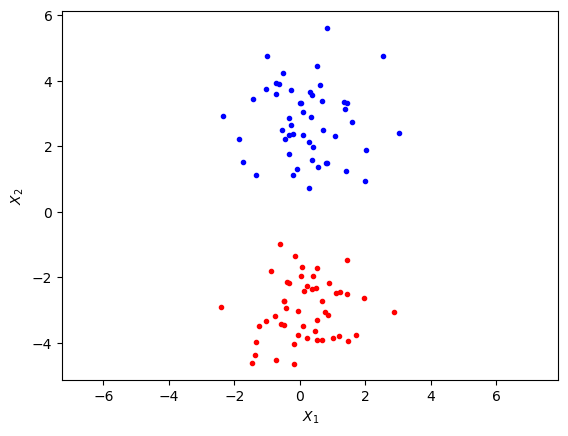

In [5]:
# generate some artificial data
X, Y = make_data_spherical()
make_plot_nclass(X,Y)
pl.axis('equal');

## Estimating Class Centroids from Training Data

In [13]:
X, Y = make_data_spherical(10000) # the elements of Y can be string, not numerical
uniqueClasses = np.unique(Y)
numClasses = len(uniqueClasses) # to handle each label(class) as number
mu = np.zeros((numClasses, X.shape[1]))
for c in range(numClasses):
    mu[c, :] = X[Y==c,:].mean(axis=0)

In [15]:
mu

array([[ 1.67786823e-03,  2.98821423e+00],
       [-1.48402243e-02, -3.00157298e+00]])

mu is almost the same value as mu = np.array([[0,3],[0,-3]]).T, because we define the distribution of datas inside the function make_data_spherical.

## Computing Distances to Class Centroids

In [21]:
x = X[-1,:]
distToMus = np.sqrt(((mu - x)**2).sum(axis=1))
distToMus
# uniqueClasses[distToMus.argmin()]
# uniqueClasses[((mu - x)**2).sum(axis=1).argmin()] # back to real label(class)

array([5.01558481, 1.44188762])

In [23]:
distToMus.min()

1.4418876209977243

In [25]:
distToMus.argmin()

1

In [27]:
distToMus[distToMus.argmin()]

1.4418876209977243

## Nearest Centroid Classification Algorithm

In [31]:
def fit_ncc(X,Y):
    '''
    Input: 
    X: samples-by-data-dimensions data matrix
    Y: label vector
    
    Output: 
    mu: class means stored in a number-of-classes-by-data-dimensions matrix
    '''

    # initialize weight vector
    cids = np.unique(Y)
    # compute class means
    mu = np.zeros((len(cids), X.shape[1]), dtype=float) # to make sure that centroid is always float
    for class_idx, class_label in enumerate(cids): # enumerate: (index, label)
        # compute centroids
        mu[class_idx, :] = X[Y==class_label,:].mean(axis=0) 

    return mu, cids # return cids: for the case when label is not 0,1,2,... but random ints or strings
    
def predict_ncc(X, mu, cids): # input cids: for the case when label is not 0,1,2,... but random ints or strings
    '''
    Performs neares centroid prediction
    
    Input: 
    X: samples-by-data-dimensions data matrix (N * D)
    mu: class means stored in a number-of-classes-by-data-dimensions matrix (K * D)
    
    Output:
    Y_predicted: prediction as vector of length samples (N,)
    '''

    # do nearest-centroid classification
    # NCdist[i, k] = Euclidean distance from X[i] to mu[k]
    NCdist = np.zeros((X.shape[0], mu.shape[0])) # X.shape[0] is N, mu.shape[0] is K(the number of classes)
    
    # compute euclidean distance to centroids

    for index_sample in range (X.shape[0]):
        NCdist[index_sample,:] = np.sqrt(((mu - X[index_sample,:])**2).sum(axis=1))
    
    # assign the class label of the nearest (euclidean distance) centroid
    index_predicted = NCdist.argmin(axis=1)
    Y_predicted = cids[index_predicted]
    
    return Y_predicted

## Applying NCC to Different Dataset Structures

In this section, the Nearest Centroid Classifier is applied to three synthetic datasets with different geometric structures. The goal is to compare how well centroid-based classification works for spherical data, correlated two-class data, and correlated three-class data.

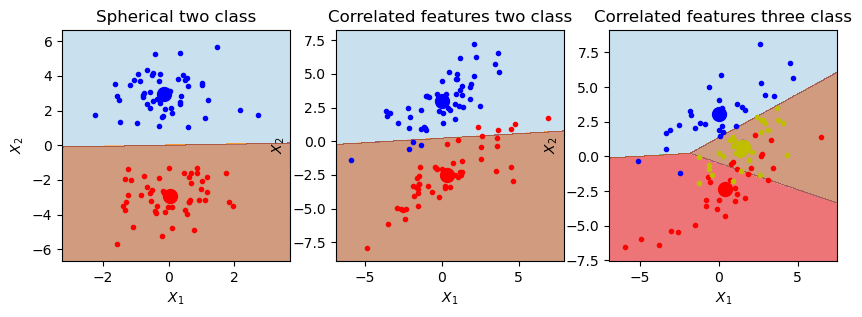

In [35]:
pl.figure(figsize=(10,3))

pl.subplot(1,3,1)
X, Y = make_data_spherical()
mu = fit_ncc(X,Y)
make_plot_nclass(X, Y, mu)
pl.title('Spherical two class')

pl.subplot(1,3,2)
X, Y = make_data_twoclass()
mu = fit_ncc(X,Y)
make_plot_nclass(X, Y, mu)
pl.title('Correlated features two class')

pl.subplot(1,3,3)
X, Y = make_data_threeclass()
mu = fit_ncc(X,Y)
make_plot_nclass(X, Y, mu)
pl.title('Correlated features three class');

## Summary of Results

The Nearest Centroid Classifier works well when each class can be represented by a central mean point. In the spherical two-class dataset, the class centroids provide a natural separation between the two groups, so the classifier is expected to perform well.

For the correlated two-class dataset, the data distribution is less symmetric, but the two classes can still be separated reasonably well using their centroids. However, the classifier does not explicitly model the covariance structure of the data, so it may be less flexible when the class shapes are elongated or strongly correlated.

In the correlated three-class dataset, the classifier extends naturally to multiple classes by assigning each point to the nearest class centroid. The result shows that NCC is simple and interpretable, but its performance depends strongly on whether the mean of each class is a good representative of the overall class distribution.